In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
    df = pd.read_csv('../data/diabetes_dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (70000, 34)

First 5 rows:


,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No


In [3]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (70000, 34)

Column Names:
['Target', 'Genetic Markers', 'Autoantibodies', 'Family History', 'Environmental Factors', 'Insulin Levels', 'Age', 'BMI', 'Physical Activity', 'Dietary Habits', 'Blood Pressure', 'Cholesterol Levels', 'Waist Circumference', 'Blood Glucose Levels', 'Ethnicity', 'Socioeconomic Factors', 'Smoking Status', 'Alcohol Consumption', 'Glucose Tolerance Test', 'History of PCOS', 'Previous Gestational Diabetes', 'Pregnancy History', 'Weight Gain During Pregnancy', 'Pancreatic Health', 'Pulmonary Function', 'Cystic Fibrosis Diagnosis', 'Steroid Use History', 'Genetic Testing', 'Neurological Assessments', 'Liver Function Tests', 'Digestive Enzyme Levels', 'Urine Test', 'Birth Weight', 'Early Onset Symptoms']

Data Types:
Target                           object
Genetic Markers                  object
Autoantibodies                   object
Family History                   object
Environmental Factors            object
Insulin Levels                    int64
Age    

In [3]:
# Mapping 13 types to 4 categories
type_mapping = {
    'Type 1 Diabetes': 'Type 1',
    'LADA': 'Type 1',
    'Wolfram Syndrome': 'Type 1',
    'Wolcott-Rallison Syndrome': 'Type 1',
    'Neonatal Diabetes Mellitus (NDM)': 'Type 1',
    'MODY': 'Type 1',
    
    'Type 2 Diabetes': 'Type 2',
    'Gestational Diabetes': 'Type 2',
    'Steroid-Induced Diabetes': 'Type 2',
    'Secondary Diabetes': 'Type 2',
    
    'Cystic Fibrosis-Related Diabetes (CFRD)': 'Type 3',
    'Type 3c Diabetes (Pancreatogenic Diabetes)': 'Type 3',
    
    'Prediabetic': 'Prediabetic'
}

df['Target'] = df['Target'].map(type_mapping)

print("New Target Distribution:")
print(df['Target'].value_counts())

New Target Distribution:
Target
Type 1         32345
Type 2         21495
Type 3         10784
Prediabetic     5376
Name: count, dtype: int64


In [4]:
# Binary columns
from sklearn.preprocessing import LabelEncoder
binary_cols = {
    'Genetic Markers': {'Negative': 0, 'Positive': 1},
    'Autoantibodies': {'Negative': 0, 'Positive': 1},
    'Family History': {'No': 0, 'Yes': 1},
    'Environmental Factors': {'Absent': 0, 'Present': 1},
    'Dietary Habits': {'Healthy': 0, 'Unhealthy': 1},
    'Ethnicity': {'High Risk': 0, 'Low Risk': 1},
    'Smoking Status': {'Non-Smoker': 0, 'Smoker': 1},
    'Glucose Tolerance Test': {'Abnormal': 0, 'Normal': 1},
    'History of PCOS': {'No': 0, 'Yes': 1},
    'Previous Gestational Diabetes': {'No': 0, 'Yes': 1},
    'Pregnancy History': {'Abnormal': 0, 'Normal': 1},
    'Cystic Fibrosis Diagnosis': {'No': 0, 'Yes': 1},
    'Steroid Use History': {'No': 0, 'Yes': 1},
    'Genetic Testing': {'Negative': 0, 'Positive': 1},
    'Liver Function Tests': {'Abnormal': 0, 'Normal': 1},
    'Early Onset Symptoms': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_cols.items():
    df[col] = df[col].map(mapping)

# Label encode remaining text columns
le = LabelEncoder()
label_cols = ['Physical Activity', 'Socioeconomic Factors', 
              'Alcohol Consumption', 'Urine Test']

for col in label_cols:
    df[col] = le.fit_transform(df[col])

# Encode target
le_target = LabelEncoder()
df['Target'] = le_target.fit_transform(df['Target'])

print("Encoding complete!")
print("\nTarget Encoding:")
for i, class_name in enumerate(le_target.classes_):
    print(f"  {class_name} → {i}")

print("\nData Types:")
print(df.dtypes)

Encoding complete!

Target Encoding:
  Prediabetic → 0
  Type 1 → 1
  Type 2 → 2
  Type 3 → 3

Data Types:
Target                             int64
Genetic Markers                    int64
Autoantibodies                     int64
Family History                     int64
Environmental Factors              int64
Insulin Levels                     int64
Age                                int64
BMI                                int64
Physical Activity                  int64
Dietary Habits                     int64
Blood Pressure                     int64
Cholesterol Levels                 int64
Waist Circumference                int64
Blood Glucose Levels               int64
Ethnicity                          int64
Socioeconomic Factors              int64
Smoking Status                     int64
Alcohol Consumption                int64
Glucose Tolerance Test             int64
History of PCOS                    int64
Previous Gestational Diabetes      int64
Pregnancy History               

In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nShape:", df.shape)

print("\nTarget Distribution:")
for i, class_name in enumerate(le_target.classes_):
    count = (df['Target'] == i).sum()
    pct = count / len(df) * 100
    print(f"  {class_name}: {count} ({pct:.1f}%)")


Missing Values:
Target                               0
Genetic Markers                      0
Autoantibodies                       0
Family History                       0
Environmental Factors                0
Insulin Levels                       0
Age                                  0
BMI                                  0
Physical Activity                    0
Dietary Habits                       0
Blood Pressure                       0
Cholesterol Levels                   0
Waist Circumference                  0
Blood Glucose Levels                 0
Ethnicity                            0
Socioeconomic Factors                0
Smoking Status                       0
Alcohol Consumption                  0
Glucose Tolerance Test               0
History of PCOS                      0
Previous Gestational Diabetes        0
Pregnancy History                34730
Weight Gain During Pregnancy         0
Pancreatic Health                    0
Pulmonary Function                   0
Cystic Fi

In [6]:
# Check actual unique values
check_cols = ['Genetic Markers', 'Autoantibodies', 
              'Family History', 'Dietary Habits']

# Reload original dataset
df = pd.read_csv('../data/diabetes_dataset.csv')

for col in check_cols:
    print(f"{col}: {df[col].unique()}")

Genetic Markers: ['Positive' 'Negative']
Autoantibodies: ['Negative' 'Positive']
Family History: ['No' 'Yes']
Dietary Habits: ['Healthy' 'Unhealthy']


In [7]:
# Reload dataset
df = pd.read_csv('../data/diabetes_dataset.csv')

# Step 1 — Map target first
type_mapping = {
    'Type 1 Diabetes': 'Type 1',
    'LADA': 'Type 1',
    'Wolfram Syndrome': 'Type 1',
    'Wolcott-Rallison Syndrome': 'Type 1',
    'Neonatal Diabetes Mellitus (NDM)': 'Type 1',
    'MODY': 'Type 1',
    'Type 2 Diabetes': 'Type 2',
    'Gestational Diabetes': 'Type 2',
    'Steroid-Induced Diabetes': 'Type 2',
    'Secondary Diabetes': 'Type 2',
    'Cystic Fibrosis-Related Diabetes (CFRD)': 'Type 3',
    'Type 3c Diabetes (Pancreatogenic Diabetes)': 'Type 3',
    'Prediabetic': 'Prediabetic'
}
df['Target'] = df['Target'].map(type_mapping)

# Step 2 — Binary encoding
binary_cols = {
    'Genetic Markers': {'Negative': 0, 'Positive': 1},
    'Autoantibodies': {'Negative': 0, 'Positive': 1},
    'Family History': {'No': 0, 'Yes': 1},
    'Environmental Factors': {'Absent': 0, 'Present': 1},
    'Dietary Habits': {'Healthy': 0, 'Unhealthy': 1},
    'Ethnicity': {'High Risk': 0, 'Low Risk': 1},
    'Smoking Status': {'Non-Smoker': 0, 'Smoker': 1},
    'Glucose Tolerance Test': {'Abnormal': 0, 'Normal': 1},
    'History of PCOS': {'No': 0, 'Yes': 1},
    'Previous Gestational Diabetes': {'No': 0, 'Yes': 1},
    'Pregnancy History': {'Abnormal': 0, 'Normal': 1},
    'Cystic Fibrosis Diagnosis': {'No': 0, 'Yes': 1},
    'Steroid Use History': {'No': 0, 'Yes': 1},
    'Genetic Testing': {'Negative': 0, 'Positive': 1},
    'Liver Function Tests': {'Abnormal': 0, 'Normal': 1},
    'Early Onset Symptoms': {'No': 0, 'Yes': 1}
}

for col, mapping in binary_cols.items():
    df[col] = df[col].map(mapping)

# Step 3 — Label encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_cols = ['Physical Activity', 'Socioeconomic Factors',
              'Alcohol Consumption', 'Urine Test']

for col in label_cols:
    df[col] = le.fit_transform(df[col])

# Step 4 — Encode target
le_target = LabelEncoder()
df['Target'] = le_target.fit_transform(df['Target'])

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Target                               0
Genetic Markers                      0
Autoantibodies                       0
Family History                       0
Environmental Factors                0
Insulin Levels                       0
Age                                  0
BMI                                  0
Physical Activity                    0
Dietary Habits                       0
Blood Pressure                       0
Cholesterol Levels                   0
Waist Circumference                  0
Blood Glucose Levels                 0
Ethnicity                            0
Socioeconomic Factors                0
Smoking Status                       0
Alcohol Consumption                  0
Glucose Tolerance Test               0
History of PCOS                      0
Previous Gestational Diabetes        0
Pregnancy History                34730
Weight Gain During Pregnancy         0
Pancreatic Health                    0
Pulmonary Function                   0
Cystic Fi

In [8]:
print(df['Pregnancy History'].unique())

[ 1. nan]


In [9]:
df_orig = pd.read_csv('../data/diabetes_dataset.csv')
print(df_orig['Pregnancy History'].unique())
print(df_orig['Pregnancy History'].value_counts())

['Normal' 'Complications']
Pregnancy History
Normal           35270
Complications    34730
Name: count, dtype: int64


In [10]:
# Fix Pregnancy History mapping
df['Pregnancy History'] = df_orig['Pregnancy History'].map(
    {'Normal': 1, 'Complications': 0}
)

print("Pregnancy History fixed!")
print(df['Pregnancy History'].value_counts())
print("\nMissing Values:", df['Pregnancy History'].isnull().sum())

Pregnancy History fixed!
Pregnancy History
1    35270
0    34730
Name: count, dtype: int64

Missing Values: 0


In [11]:
print("Missing Values:")
print(df.isnull().sum().sum())

print("\nShape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())

print("\nFirst 5 rows:")
df.head()

Missing Values:
0

Shape: (70000, 34)

Data Types:
int64    34
Name: count, dtype: int64

First 5 rows:


,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,2,1,0,0,1,40,44,38,0,0,...,76,0,0,1,3,1,56,1,2629,0
1,1,1,0,0,1,13,1,17,0,0,...,60,1,0,0,1,1,28,0,1881,1
2,0,1,1,1,1,27,36,24,0,1,...,80,1,0,0,1,0,55,1,3622,1
3,1,0,1,0,1,8,7,16,1,1,...,89,1,0,1,2,0,60,1,3542,0
4,1,0,0,1,1,17,10,17,0,0,...,41,0,0,1,1,1,24,3,1770,0


In [12]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Target                           0
Genetic Markers                  0
Autoantibodies                   0
Family History                   0
Environmental Factors            0
Insulin Levels                   0
Age                              0
BMI                              0
Physical Activity                0
Dietary Habits                   0
Blood Pressure                   0
Cholesterol Levels               0
Waist Circumference              0
Blood Glucose Levels             0
Ethnicity                        0
Socioeconomic Factors            0
Smoking Status                   0
Alcohol Consumption              0
Glucose Tolerance Test           0
History of PCOS                  0
Previous Gestational Diabetes    0
Pregnancy History                0
Weight Gain During Pregnancy     0
Pancreatic Health                0
Pulmonary Function               0
Cystic Fibrosis Diagnosis        0
Steroid Use History              0
Genetic Testing             

In [13]:
df.to_csv('../data/diabetes_dataset_clean.csv', index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


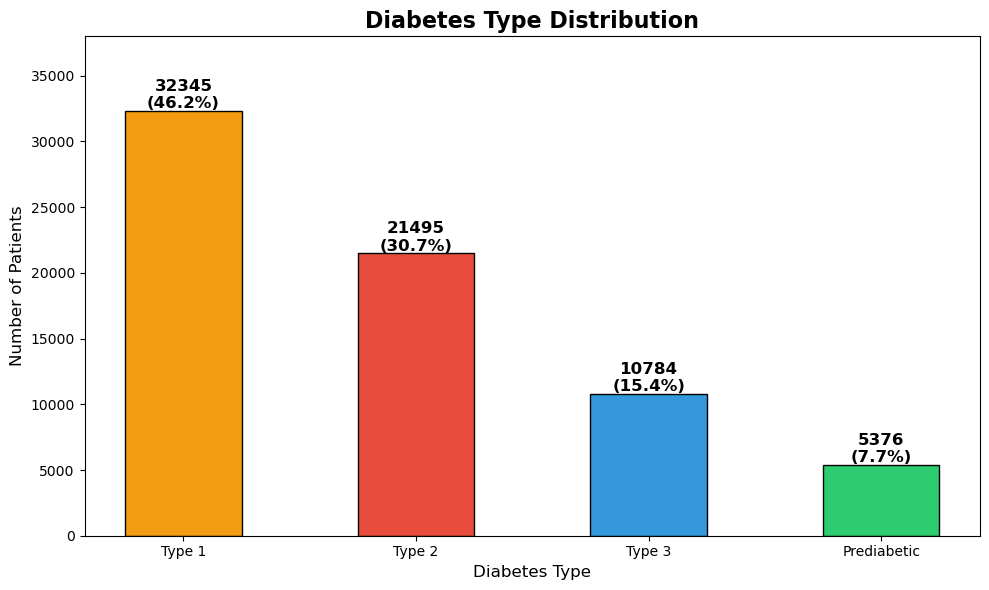

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

type_counts = df['Target'].value_counts()
type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
type_counts.index = [type_labels[i] for i in type_counts.index]

plt.figure(figsize=(10, 6))
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']
bars = plt.bar(type_counts.index, type_counts.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, type_counts.values):
    pct = val / len(df) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val}\n({pct:.1f}%)', ha='center',
             fontsize=12, fontweight='bold')

plt.title('Diabetes Type Distribution',
          fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.ylim(0, 38000)

plt.tight_layout()
plt.savefig('../plots/d2_01_type_distribution.png', dpi=150)
plt.show()

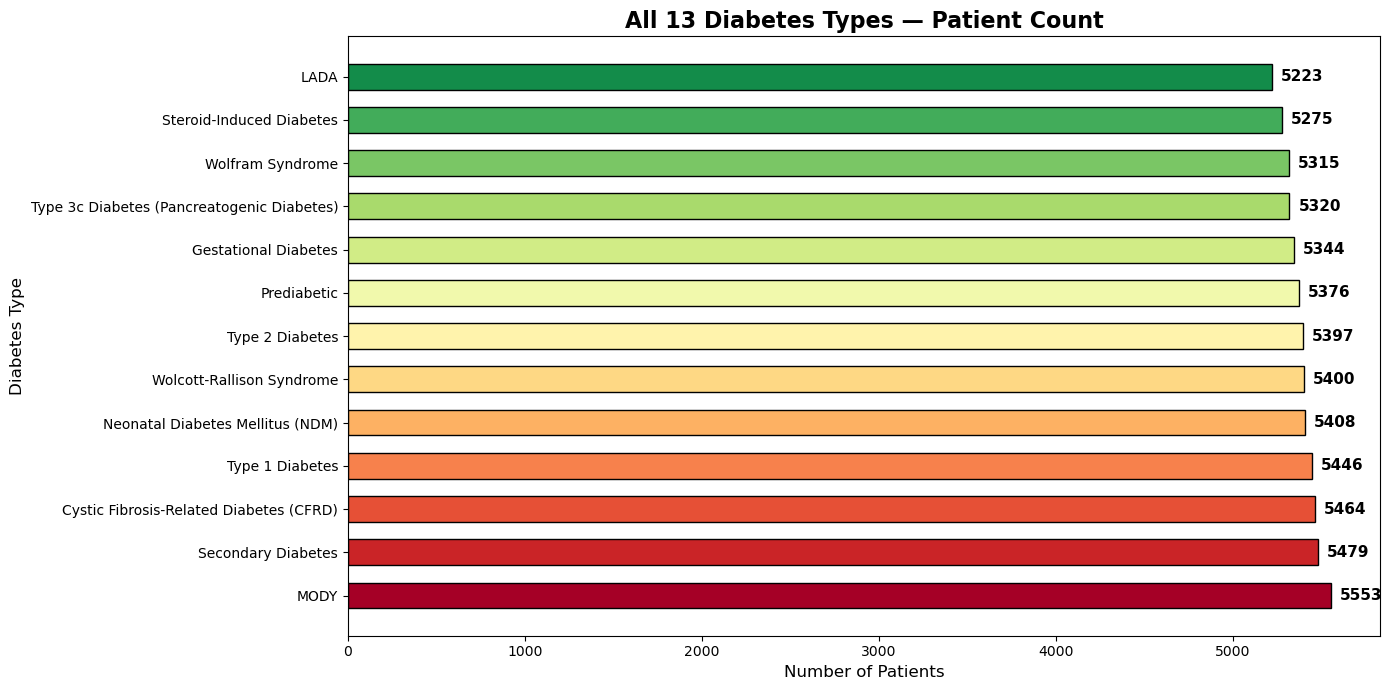

In [19]:
df_orig = pd.read_csv('../data/diabetes_dataset.csv')

type_counts = df_orig['Target'].value_counts()

plt.figure(figsize=(14, 7))
colors = plt.cm.RdYlGn([x/13 for x in range(13)])
bars = plt.barh(type_counts.index, type_counts.values,
                color=colors, edgecolor='black', height=0.6)

for bar, val in zip(bars, type_counts.values):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center',
             fontsize=11, fontweight='bold')

plt.title('All 13 Diabetes Types — Patient Count',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Diabetes Type', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/d2_01_all_types.png', dpi=150)
plt.show()

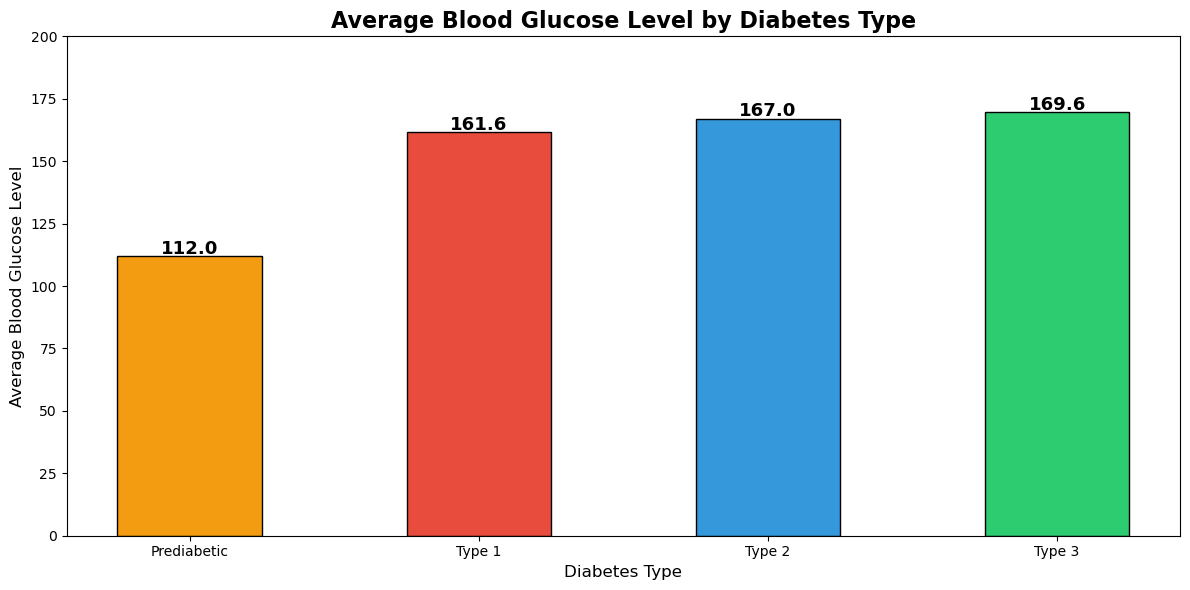

In [20]:
plt.figure(figsize=(12, 6))

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']

glucose_means = df.groupby('Target')['Blood Glucose Levels'].mean()
glucose_means.index = [type_labels[i] for i in glucose_means.index]

bars = plt.bar(glucose_means.index, glucose_means.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, glucose_means.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Average Blood Glucose Level by Diabetes Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Type', fontsize=12)
plt.ylabel('Average Blood Glucose Level', fontsize=12)
plt.ylim(0, 200)

plt.tight_layout()
plt.savefig('../plots/d2_02_glucose_type.png', dpi=150)
plt.show()

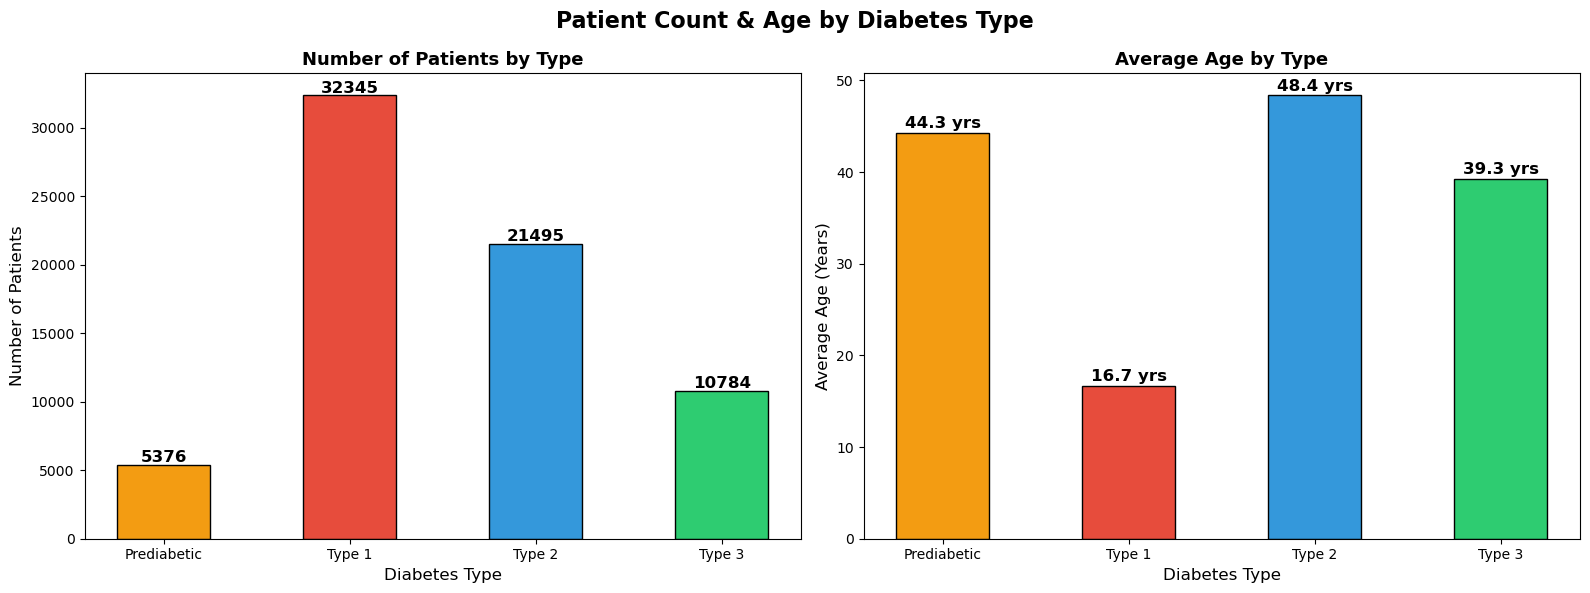

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']

# Plot 1 — Patient Count
type_counts = df['Target'].value_counts().sort_index()
type_counts.index = [type_labels[i] for i in type_counts.index]

bars1 = axes[0].bar(type_counts.index, type_counts.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars1, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val}', ha='center',
                 fontsize=12, fontweight='bold')
axes[0].set_title('Number of Patients by Type',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diabetes Type', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=12)

# Plot 2 — Average Age
age_means = df.groupby('Target')['Age'].mean().sort_index()
age_means.index = [type_labels[i] for i in age_means.index]

bars2 = axes[1].bar(age_means.index, age_means.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars2, age_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f} yrs', ha='center',
                 fontsize=12, fontweight='bold')
axes[1].set_title('Average Age by Type',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diabetes Type', fontsize=12)
axes[1].set_ylabel('Average Age (Years)', fontsize=12)

plt.suptitle('Patient Count & Age by Diabetes Type',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/d2_03_age_type.png', dpi=150)
plt.show()

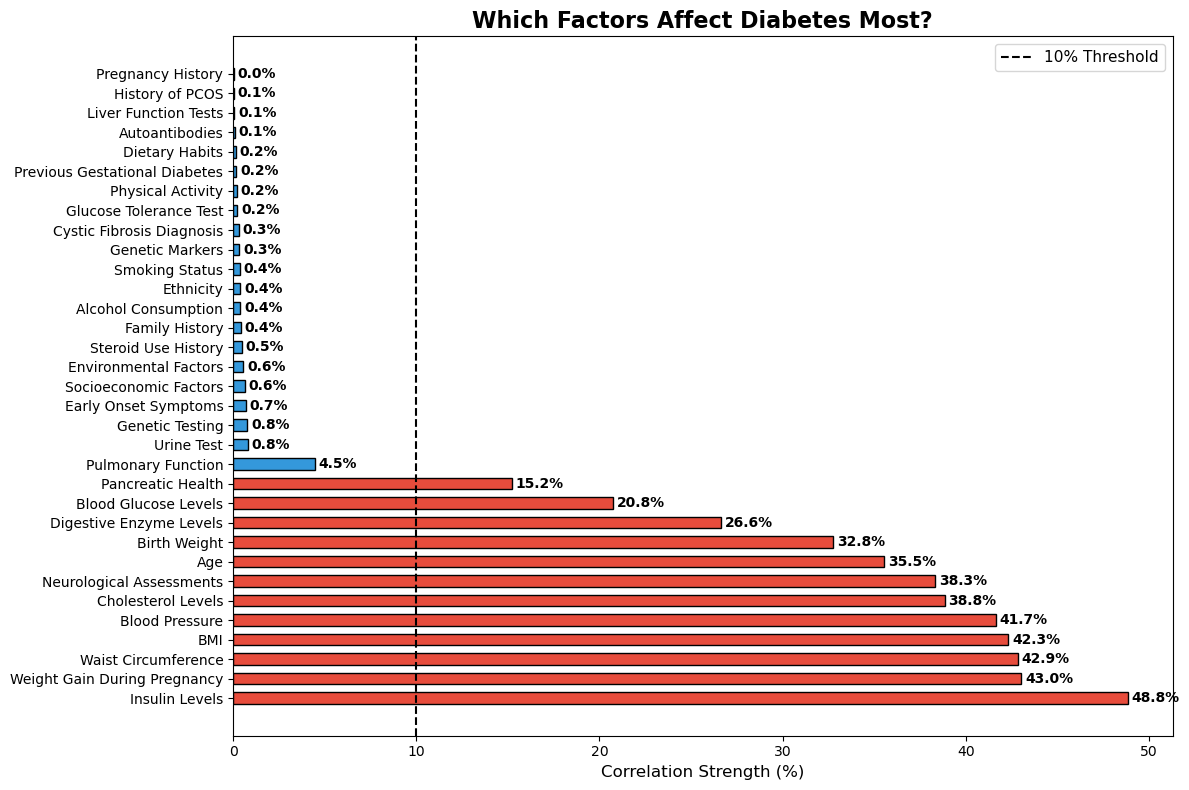

In [25]:
corr = df.corr()['Target'].drop('Target').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#E74C3C' if v > 0.1 else '#3498DB' for v in corr.values]

bars = plt.barh(corr.index, corr.values * 100,
                color=colors, edgecolor='black', height=0.6)

for bar, val in zip(bars, corr.values * 100):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center',
             fontsize=10, fontweight='bold')

plt.axvline(10, color='black', linestyle='--', 
            linewidth=1.5, label='10% Threshold')

plt.title('Which Factors Affect Diabetes Most?',
          fontsize=16, fontweight='bold')
plt.xlabel('Correlation Strength (%)', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../plots/d2_04_correlation.png', dpi=150)
plt.show()

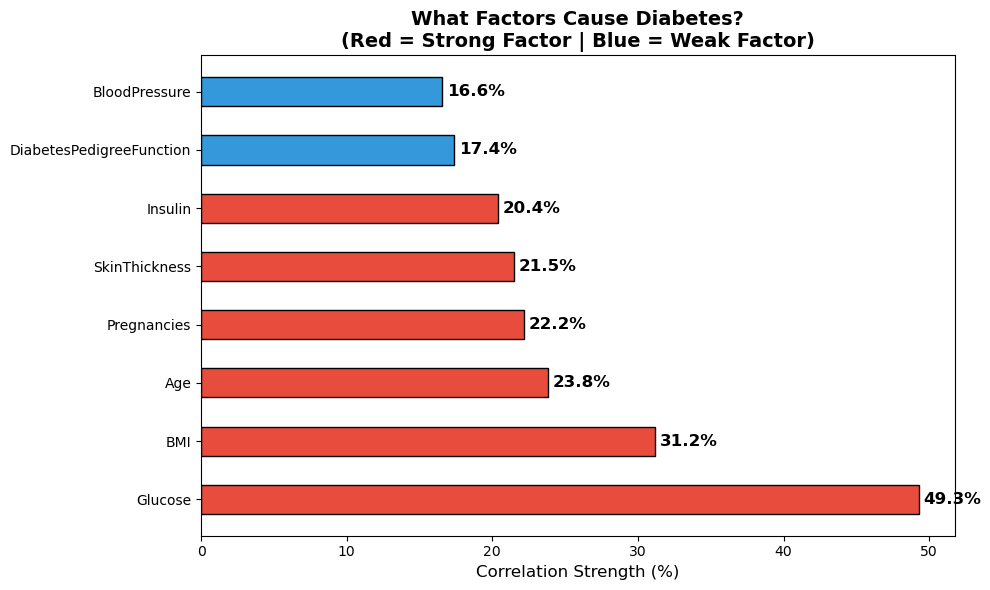

In [24]:
df_old = pd.read_csv('../data/diabetes_clean.csv')

corr_old = df_old.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#E74C3C' if v > 0.2 else '#3498DB' for v in corr_old.values]

bars = plt.barh(corr_old.index, corr_old.values * 100,
                color=colors, edgecolor='black', height=0.5)

for bar, val in zip(bars, corr_old.values * 100):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center',
             fontsize=12, fontweight='bold')

plt.title('What Factors Cause Diabetes?\n(Red = Strong Factor | Blue = Weak Factor)',
          fontsize=14, fontweight='bold')
plt.xlabel('Correlation Strength (%)', fontsize=12)

plt.tight_layout()
plt.savefig('../plots/d2_05_causes.png', dpi=150)
plt.show()

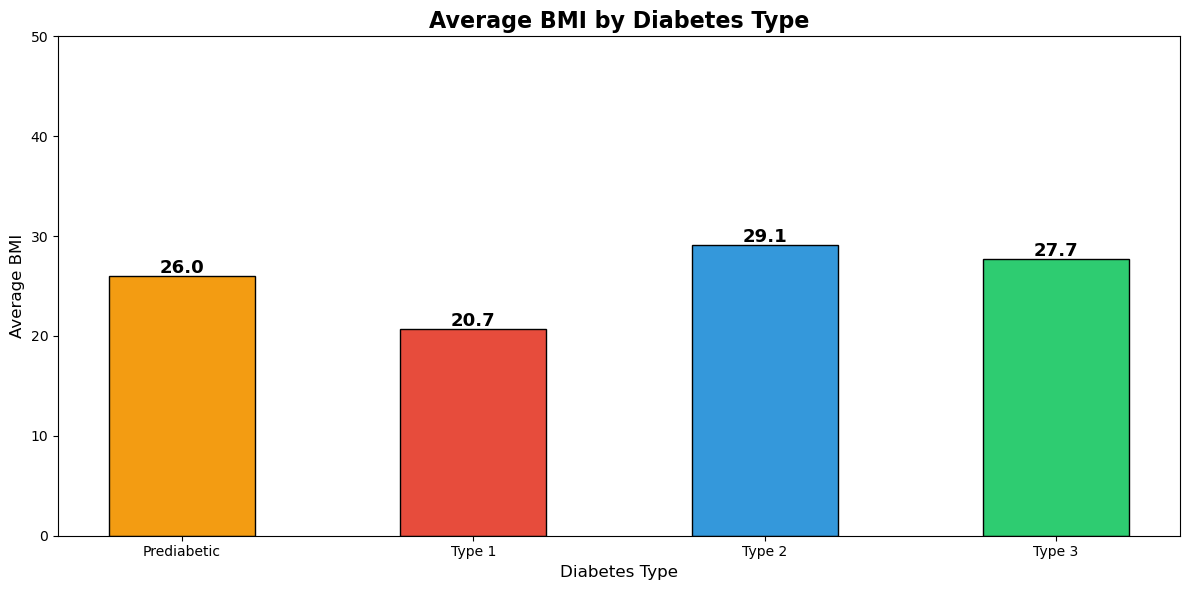

In [32]:
plt.figure(figsize=(12, 6))

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']

bmi_means = df.groupby('Target')['BMI'].mean().sort_index()
bmi_means.index = [type_labels[i] for i in bmi_means.index]

bars = plt.bar(bmi_means.index, bmi_means.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, bmi_means.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Average BMI by Diabetes Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Type', fontsize=12)
plt.ylabel('Average BMI', fontsize=12)
plt.ylim(0, 50)

plt.tight_layout()
plt.savefig('../plots/d2_07_bmi_type.png', dpi=150)
plt.show()

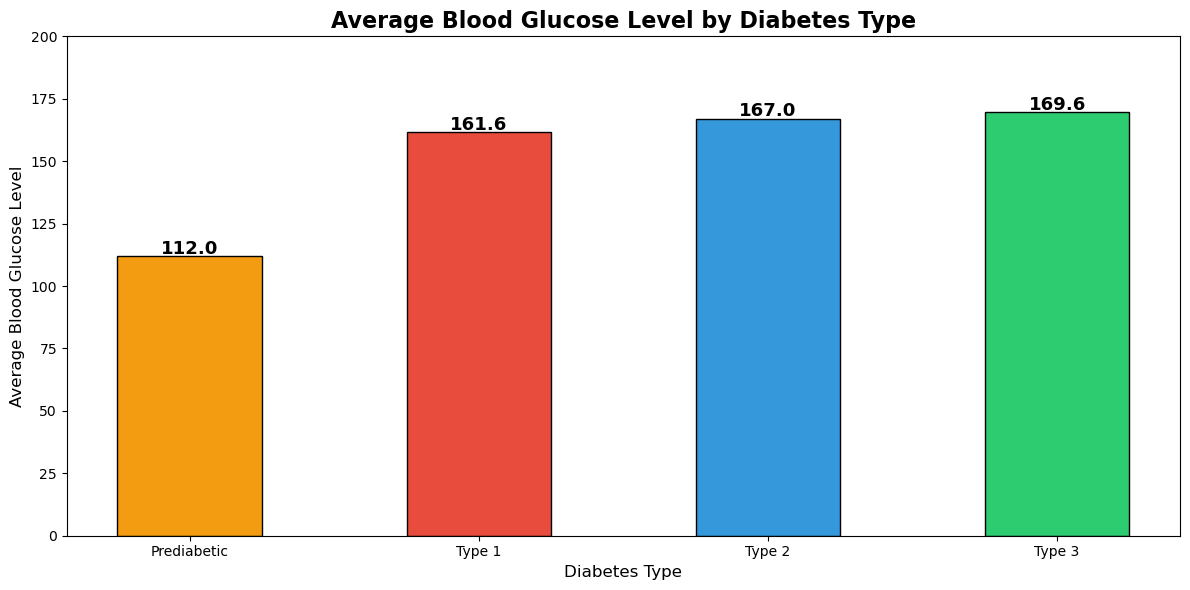

In [33]:
plt.figure(figsize=(12, 6))

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']

glucose_means = df.groupby('Target')['Blood Glucose Levels'].mean().sort_index()
glucose_means.index = [type_labels[i] for i in glucose_means.index]

bars = plt.bar(glucose_means.index, glucose_means.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, glucose_means.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}', ha='center',
             fontsize=13, fontweight='bold')

plt.title('Average Blood Glucose Level by Diabetes Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Type', fontsize=12)
plt.ylabel('Average Blood Glucose Level', fontsize=12)
plt.ylim(0, 200)

plt.tight_layout()
plt.savefig('../plots/d2_02_glucose_type.png', dpi=150)
plt.show()

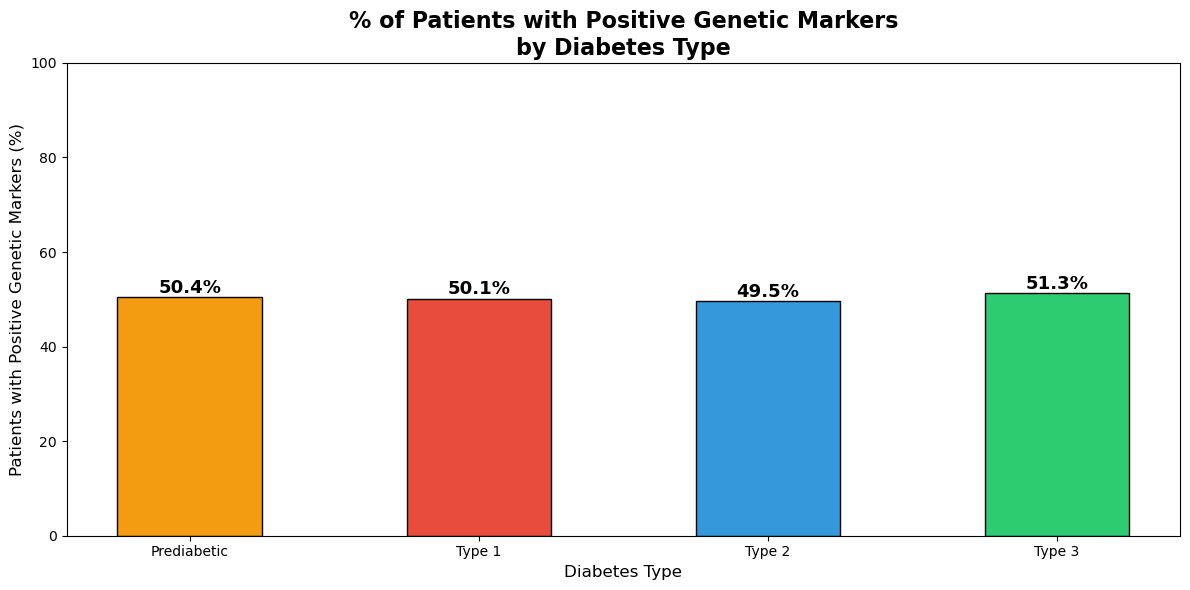

In [34]:
plt.figure(figsize=(12, 6))

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']

genetic_means = df.groupby('Target')['Genetic Markers'].mean() * 100
genetic_means.index = [type_labels[i] for i in genetic_means.index]

bars = plt.bar(genetic_means.index, genetic_means.values,
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, genetic_means.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=13, fontweight='bold')

plt.title('% of Patients with Positive Genetic Markers\nby Diabetes Type',
          fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Type', fontsize=12)
plt.ylabel('Patients with Positive Genetic Markers (%)', fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('../plots/d2_08_genetic.png', dpi=150)
plt.show()

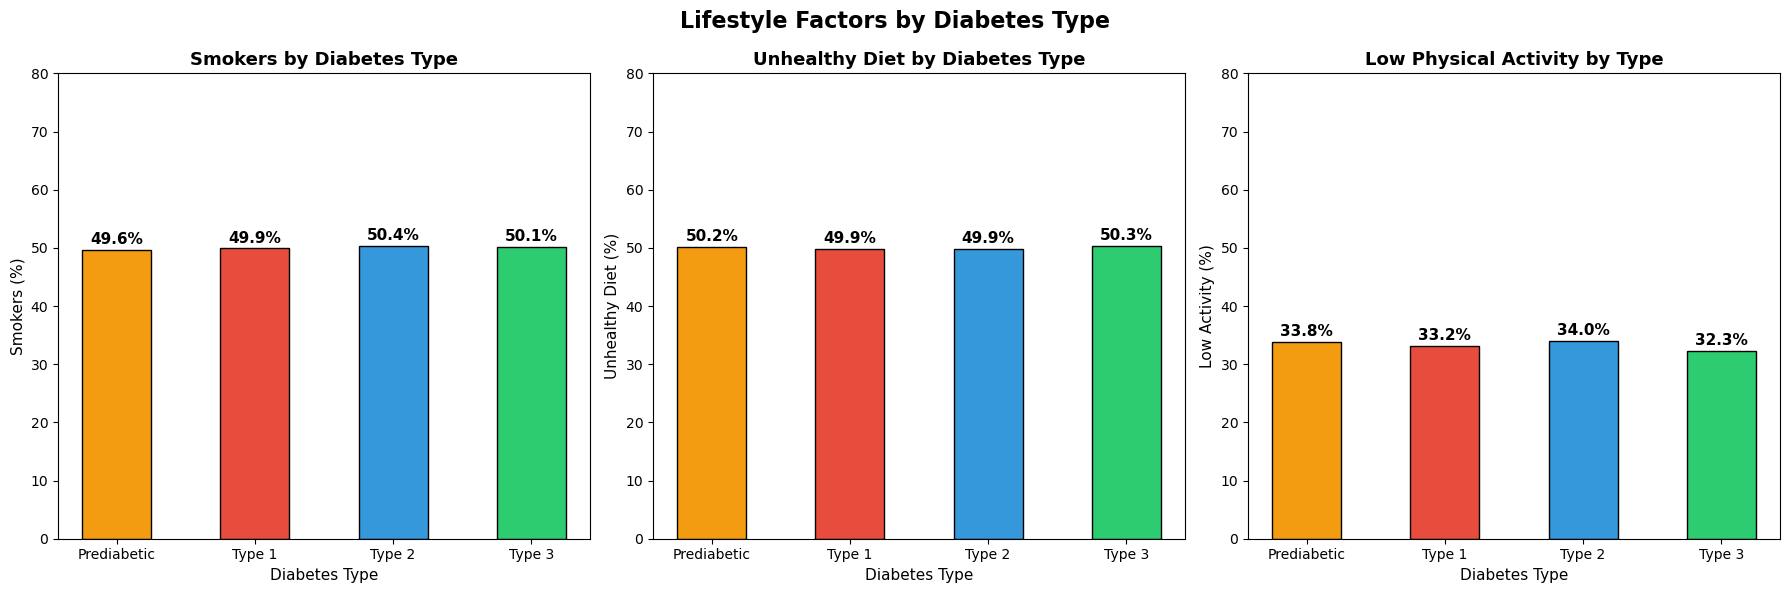

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
colors = ['#F39C12', '#E74C3C', '#3498DB', '#2ECC71']

# Plot 1 — Smoking
smoking_means = df.groupby('Target')['Smoking Status'].mean() * 100
smoking_means.index = [type_labels[i] for i in smoking_means.index]
bars1 = axes[0].bar(smoking_means.index, smoking_means.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars1, smoking_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Smokers by Diabetes Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diabetes Type', fontsize=11)
axes[0].set_ylabel('Smokers (%)', fontsize=11)
axes[0].set_ylim(0, 80)

# Plot 2 — Dietary Habits
diet_means = df.groupby('Target')['Dietary Habits'].mean() * 100
diet_means.index = [type_labels[i] for i in diet_means.index]
bars2 = axes[1].bar(diet_means.index, diet_means.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars2, diet_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center',
                 fontsize=11, fontweight='bold')
axes[1].set_title('Unhealthy Diet by Diabetes Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diabetes Type', fontsize=11)
axes[1].set_ylabel('Unhealthy Diet (%)', fontsize=11)
axes[1].set_ylim(0, 80)

# Plot 3 — Physical Activity (Low)
df['Low Activity'] = (df['Physical Activity'] == 1).astype(int)
activity_means = df.groupby('Target')['Low Activity'].mean() * 100
activity_means.index = [type_labels[i] for i in activity_means.index]
bars3 = axes[2].bar(activity_means.index, activity_means.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars3, activity_means.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.1f}%', ha='center',
                 fontsize=11, fontweight='bold')
axes[2].set_title('Low Physical Activity by Type', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Diabetes Type', fontsize=11)
axes[2].set_ylabel('Low Activity (%)', fontsize=11)
axes[2].set_ylim(0, 80)

plt.suptitle('Lifestyle Factors by Diabetes Type',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/d2_09_lifestyle.png', dpi=150)
plt.show()

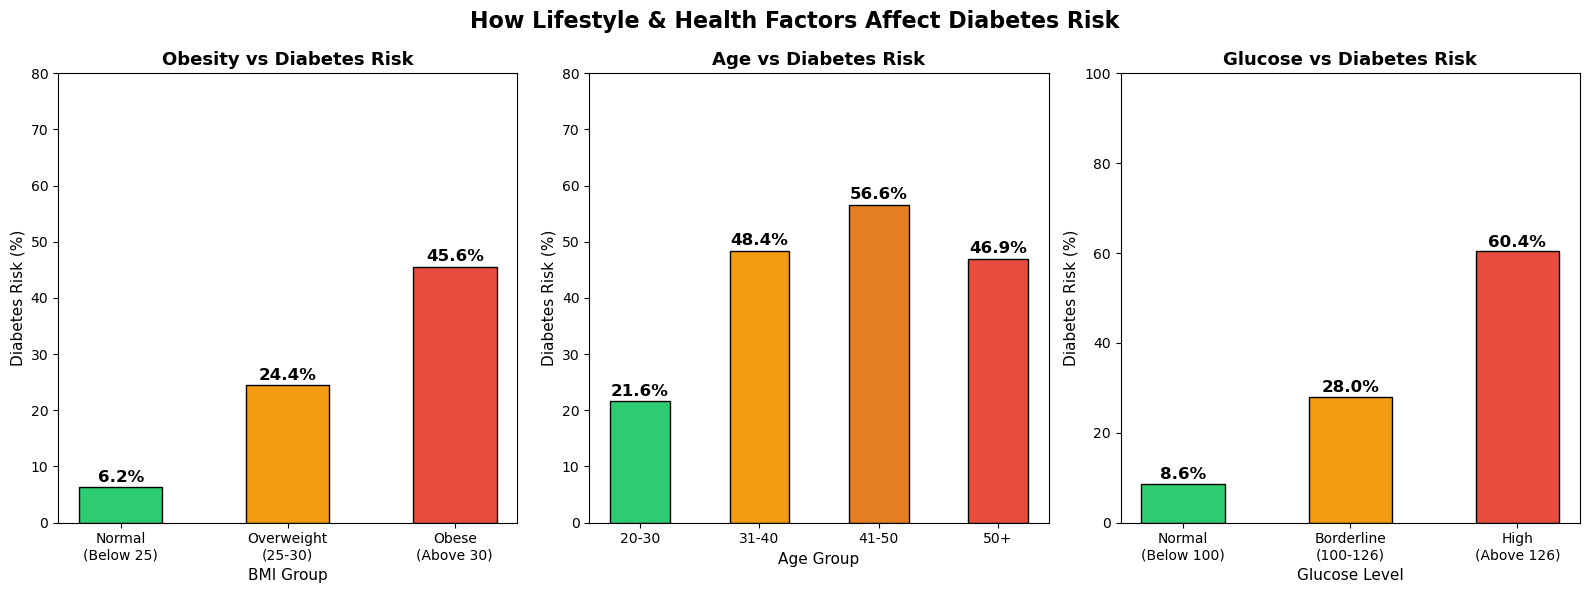

In [36]:
df_old = pd.read_csv('../data/diabetes_clean.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# BMI groups
df_old['BMI_Group'] = pd.cut(df_old['BMI'],
                              bins=[0, 25, 30, 70],
                              labels=['Normal\n(Below 25)', 
                                      'Overweight\n(25-30)', 
                                      'Obese\n(Above 30)'])

bmi_rate = df_old.groupby('BMI_Group')['Outcome'].mean() * 100
axes[0].bar(bmi_rate.index, bmi_rate.values,
            color=['#2ECC71', '#F39C12', '#E74C3C'],
            edgecolor='black', width=0.5)
for i, val in enumerate(bmi_rate.values):
    axes[0].text(i, val + 1, f'{val:.1f}%',
                ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Obesity vs Diabetes Risk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BMI Group', fontsize=11)
axes[0].set_ylabel('Diabetes Risk (%)', fontsize=11)
axes[0].set_ylim(0, 80)

# Age groups
df_old['Age_Group'] = pd.cut(df_old['Age'],
                              bins=[20, 30, 40, 50, 81],
                              labels=['20-30', '31-40', '41-50', '50+'])
age_rate = df_old.groupby('Age_Group')['Outcome'].mean() * 100
axes[1].bar(age_rate.index, age_rate.values,
            color=['#2ECC71', '#F39C12', '#E67E22', '#E74C3C'],
            edgecolor='black', width=0.5)
for i, val in enumerate(age_rate.values):
    axes[1].text(i, val + 1, f'{val:.1f}%',
                ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Age vs Diabetes Risk', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Diabetes Risk (%)', fontsize=11)
axes[1].set_ylim(0, 80)

# Glucose groups
df_old['Glucose_Group'] = pd.cut(df_old['Glucose'],
                                  bins=[0, 100, 126, 200],
                                  labels=['Normal\n(Below 100)', 
                                          'Borderline\n(100-126)', 
                                          'High\n(Above 126)'])
glucose_rate = df_old.groupby('Glucose_Group')['Outcome'].mean() * 100
axes[2].bar(glucose_rate.index, glucose_rate.values,
            color=['#2ECC71', '#F39C12', '#E74C3C'],
            edgecolor='black', width=0.5)
for i, val in enumerate(glucose_rate.values):
    axes[2].text(i, val + 1, f'{val:.1f}%',
                ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Glucose vs Diabetes Risk', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Glucose Level', fontsize=11)
axes[2].set_ylabel('Diabetes Risk (%)', fontsize=11)
axes[2].set_ylim(0, 100)

plt.suptitle('How Lifestyle & Health Factors Affect Diabetes Risk',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/lifestyle_diabetes_risk.png', dpi=150)
plt.show()

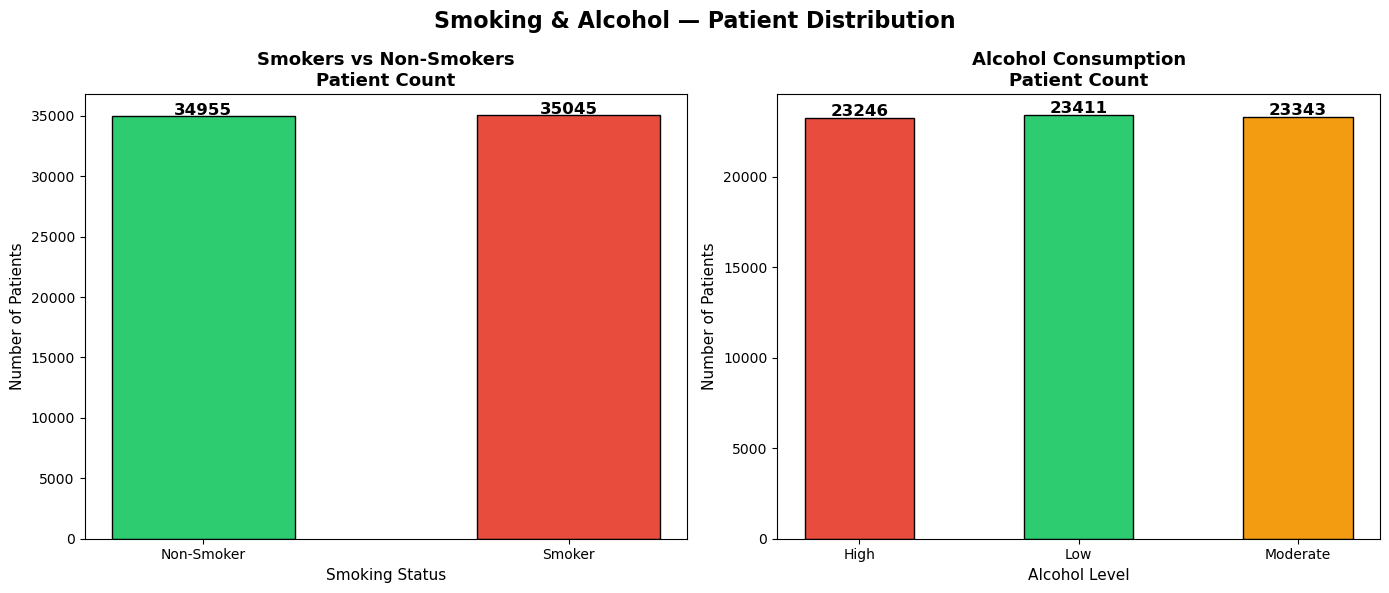

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Smokers vs Non-Smokers count (keep this)
smoker_counts = df_new['Smoking Status'].value_counts().sort_index()

axes[0].bar(['Non-Smoker', 'Smoker'],
            [smoker_counts[0], smoker_counts[1]],
            color=['#2ECC71', '#E74C3C'],
            edgecolor='black', width=0.5)
for i, val in enumerate([smoker_counts[0], smoker_counts[1]]):
    axes[0].text(i, val + 100, f'{val}',
                ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Smokers vs Non-Smokers\nPatient Count',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Smoking Status', fontsize=11)
axes[0].set_ylabel('Number of Patients', fontsize=11)

# Plot 2 — Alcohol vs Non-Alcohol count
alcohol_counts = df_new['Alcohol Consumption'].value_counts().sort_index()
alcohol_labels = {0: 'High', 1: 'Low', 2: 'Moderate'}
alcohol_counts.index = [alcohol_labels[i] for i in alcohol_counts.index]

axes[1].bar(alcohol_counts.index, alcohol_counts.values,
            color=['#E74C3C', '#2ECC71', '#F39C12'],
            edgecolor='black', width=0.5)
for i, val in enumerate(alcohol_counts.values):
    axes[1].text(i, val + 100, f'{val}',
                ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Alcohol Consumption\nPatient Count',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Alcohol Level', fontsize=11)
axes[1].set_ylabel('Number of Patients', fontsize=11)

plt.suptitle('Smoking & Alcohol — Patient Distribution',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/d2_11_smoking_alcohol.png', dpi=150)
plt.show()

In [15]:
import sys
!{sys.executable} -m pip install xgboost

In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('../data/diabetes_dataset_clean.csv')

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 56000
Testing samples: 14000


In [17]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Prediabetic', 'Type 1', 'Type 2', 'Type 3']))

Accuracy: 95.07%

Classification Report:
              precision    recall  f1-score   support

 Prediabetic       0.97      1.00      0.98      1089
      Type 1       0.97      0.99      0.98      6521
      Type 2       0.97      0.90      0.93      4256
      Type 3       0.87      0.90      0.88      2134

    accuracy                           0.95     14000
   macro avg       0.94      0.95      0.94     14000
weighted avg       0.95      0.95      0.95     14000



In [18]:
import pickle

# Save model
with open('../models/diabetes2_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save label encoder
with open('../models/diabetes2_label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

print("Model saved successfully!")
print("Label encoder saved successfully!")

Model saved successfully!
Label encoder saved successfully!


In [19]:
# Sample patient data
sample_patient = {
    'Genetic Markers': 1,        # Positive
    'Autoantibodies': 1,         # Positive
    'Family History': 1,         # Yes
    'Environmental Factors': 1,  # Present
    'Insulin Levels': 50,
    'Age': 25,
    'BMI': 22,
    'Physical Activity': 1,      # Low
    'Dietary Habits': 1,         # Unhealthy
    'Blood Pressure': 120,
    'Cholesterol Levels': 180,
    'Waist Circumference': 80,
    'Blood Glucose Levels': 160,
    'Ethnicity': 0,              # High Risk
    'Socioeconomic Factors': 1,  # Low
    'Smoking Status': 1,         # Smoker
    'Alcohol Consumption': 0,    # High
    'Glucose Tolerance Test': 0, # Abnormal
    'History of PCOS': 0,        # No
    'Previous Gestational Diabetes': 0, # No
    'Pregnancy History': 1,      # Normal
    'Weight Gain During Pregnancy': 10,
    'Pancreatic Health': 50,
    'Pulmonary Function': 70,
    'Cystic Fibrosis Diagnosis': 0, # No
    'Steroid Use History': 0,    # No
    'Genetic Testing': 1,        # Positive
    'Neurological Assessments': 2,
    'Liver Function Tests': 1,   # Normal
    'Digestive Enzyme Levels': 50,
    'Urine Test': 1,             # Ketones Present
    'Birth Weight': 3000,
    'Early Onset Symptoms': 1    # Yes
}

sample_df = pd.DataFrame([sample_patient])
prediction = xgb_model.predict(sample_df)

type_labels = {0: 'Prediabetic', 1: 'Type 1', 2: 'Type 2', 3: 'Type 3'}
print(f"Predicted Diabetes Type: {type_labels[prediction[0]]}")

Predicted Diabetes Type: Type 2


In [20]:
def predict_diabetes(patient_data):
    
    sample_df = pd.DataFrame([patient_data])
    prediction = xgb_model.predict(sample_df)[0]
    probability = xgb_model.predict_proba(sample_df)[0]
    
    type_info = {
        0: {
            'name': 'Prediabetic',
            'description': 'Your blood sugar is higher than normal but not yet diabetic.',
            'risk': 'Moderate',
            'action': 'Lifestyle changes can REVERSE this condition!',
            'diet': 'Reduce sugar and carbohydrates intake.',
            'exercise': '30 minutes walking daily recommended.'
        },
        1: {
            'name': 'Type 1 Diabetes',
            'description': 'Your immune system is attacking insulin-producing cells.',
            'risk': 'High',
            'action': 'Insulin injections required immediately. See a doctor!',
            'diet': 'Strict carbohydrate counting required.',
            'exercise': 'Regular exercise helps but monitor blood sugar.'
        },
        2: {
            'name': 'Type 2 Diabetes',
            'description': 'Your body is not using insulin properly due to lifestyle factors.',
            'risk': 'High',
            'action': 'Medication + lifestyle changes required immediately.',
            'diet': 'Avoid processed foods, sugar and refined carbs.',
            'exercise': 'Daily exercise is critical for managing Type 2.'
        },
        3: {
            'name': 'Type 3 Diabetes',
            'description': 'Diabetes caused by organ damage (pancreas or liver).',
            'risk': 'Very High',
            'action': 'Immediate medical attention required!',
            'diet': 'Strict medical diet — consult a dietitian.',
            'exercise': 'Light exercise only — consult doctor first.'
        }
    }
    
    info = type_info[prediction]
    confidence = probability[prediction] * 100
    
    print("=" * 55)
    print("         MEDIRISK — DIABETES PREDICTION REPORT")
    print("=" * 55)
    print(f"\nDiagnosis    : {info['name']}")
    print(f"Confidence   : {confidence:.1f}%")
    print(f"Risk Level   : {info['risk']}")
    print(f"\nWhat it means: {info['description']}")
    print(f"\nAction needed: {info['action']}")
    print(f"\nDiet advice  : {info['diet']}")
    print(f"\nExercise     : {info['exercise']}")
    print("\n⚠️  This is not a substitute for professional medical advice!")
    print("=" * 55)

# Test with sample patient
predict_diabetes(sample_patient)

         MEDIRISK — DIABETES PREDICTION REPORT

Diagnosis    : Type 2 Diabetes
Confidence   : 83.4%
Risk Level   : High

What it means: Your body is not using insulin properly due to lifestyle factors.

Action needed: Medication + lifestyle changes required immediately.

Diet advice  : Avoid processed foods, sugar and refined carbs.

Exercise     : Daily exercise is critical for managing Type 2.

⚠️  This is not a substitute for professional medical advice!


In [21]:
type1_patient = {
    'Genetic Markers': 1,        # Positive
    'Autoantibodies': 1,         # Positive — immune attack!
    'Family History': 1,         # Yes
    'Environmental Factors': 1,  # Present
    'Insulin Levels': 10,        # Very Low — body not producing!
    'Age': 12,                   # Child
    'BMI': 18,                   # Underweight
    'Physical Activity': 2,      # Moderate
    'Dietary Habits': 0,         # Healthy
    'Blood Pressure': 100,
    'Cholesterol Levels': 150,
    'Waist Circumference': 60,
    'Blood Glucose Levels': 250, # Very High!
    'Ethnicity': 0,
    'Socioeconomic Factors': 1,
    'Smoking Status': 0,         # Non-Smoker
    'Alcohol Consumption': 1,    # Low
    'Glucose Tolerance Test': 0, # Abnormal
    'History of PCOS': 0,
    'Previous Gestational Diabetes': 0,
    'Pregnancy History': 1,
    'Weight Gain During Pregnancy': 0,
    'Pancreatic Health': 20,     # Very Poor!
    'Pulmonary Function': 80,
    'Cystic Fibrosis Diagnosis': 0,
    'Steroid Use History': 0,
    'Genetic Testing': 1,        # Positive
    'Neurological Assessments': 1,
    'Liver Function Tests': 1,
    'Digestive Enzyme Levels': 30,
    'Urine Test': 1,             # Ketones Present
    'Birth Weight': 3200,
    'Early Onset Symptoms': 1    # Yes — early onset!
}

predict_diabetes(type1_patient)

         MEDIRISK — DIABETES PREDICTION REPORT

Diagnosis    : Type 1 Diabetes
Confidence   : 99.9%
Risk Level   : High

What it means: Your immune system is attacking insulin-producing cells.

Action needed: Insulin injections required immediately. See a doctor!

Diet advice  : Strict carbohydrate counting required.

Exercise     : Regular exercise helps but monitor blood sugar.

⚠️  This is not a substitute for professional medical advice!
